In [2]:
!pip install kaggle wandb onnx -Uq
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
! rm -rf ~/.kaggle
! mkdir ~/.kaggle

In [4]:
! cp "/content/drive/MyDrive/Colab Notebooks/kaggle_API_credentials/kaggle.json" ~/.kaggle/kaggle.json

In [5]:
! chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d fer2013

100% 285M/285M [00:03<00:00, 97.5MB/s]



In [7]:
from google.colab import userdata
wandb_key = userdata.get('WANDB_API_KEY')

import wandb
wandb.login(key=wandb_key)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ngval22 (ngval22-s) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Imports

In [8]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cpu


In [9]:
train_df = pd.read_csv('./fer2013/train.csv')
test_df = pd.read_csv('./fer2013/test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (28709, 2)
Test shape: (7178, 1)


In [10]:
print("=== TRAIN ===")
print("Null counts:\n", train_df.isnull().sum())
print("Duplicate rows:", train_df.duplicated().sum())

print("\n=== TEST ===")
print("Null counts:\n", test_df.isnull().sum())
print("Duplicate rows:", test_df.duplicated().sum())

=== TRAIN ===
Null counts:
 emotion    0
pixels     0
dtype: int64
Duplicate rows: 1194

=== TEST ===
Null counts:
 pixels    0
dtype: int64
Duplicate rows: 86


## Data validity

In [11]:
valid_labels = set(range(7))
actual_labels = set(train_df['emotion'].unique())

print("Unique emotion labels:", sorted(actual_labels))
print("All labels valid (0-6):", actual_labels == valid_labels)
print("Label dtype:", train_df['emotion'].dtype)

Unique emotion labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
All labels valid (0-6): True
Label dtype: int64


In [12]:
pixel_lengths = train_df['pixels'].str.split().apply(len)

print("Expected pixel count per image:", 48 * 48)
print("All images have correct pixel count:", (pixel_lengths == 48 * 48).all())

# Same for test
pixel_lengths_test = test_df['pixels'].str.split().apply(len)
print("\nTest set — all images have correct pixel count:", (pixel_lengths_test == 48 * 48).all())

Expected pixel count per image: 2304
Min pixel count found: 2304
Max pixel count found: 2304
All images have correct pixel count: True

Test set — all images have correct pixel count: True


In [13]:
sample_pixels = train_df['pixels'].iloc[0].split()
sample_array = np.array(sample_pixels, dtype=np.uint8)

all_pixels = train_df['pixels'].str.split(expand=True).astype(float)
global_min = all_pixels.min().min()
global_max = all_pixels.max().max()

print("All values in valid uint8 range [0, 255]:", global_min >= 0 and global_max <= 255)

Global pixel min: 0.0
Global pixel max: 255.0
All values in valid uint8 range [0, 255]: True


In [14]:
emotion_labels = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

counts = train_df['emotion'].value_counts().sort_index()
total = len(train_df)

print(f"{'Class':<5} {'Label':<12} {'Count':<8} {'% of Total'}")
print("-" * 38)
for idx, count in counts.items():
    print(f"{idx:<5} {emotion_labels[idx]:<12} {count:<8} {count/total*100:.2f}%")

Class Label        Count    % of Total
--------------------------------------
0     Angry        3995     13.92%
1     Disgust      436      1.52%
2     Fear         4097     14.27%
3     Happy        7215     25.13%
4     Sad          4830     16.82%
5     Surprise     3171     11.05%
6     Neutral      4965     17.29%


### notice that disgust is underrepresented in training set

In [15]:
counts = train_df['emotion'].value_counts().sort_index()

majority_class = counts.idxmax()
minority_class = counts.idxmin()

print(f"Majority class: {emotion_labels[majority_class]} ({counts[majority_class]} samples)")
print(f"Minority class: {emotion_labels[minority_class]} ({counts[minority_class]} samples)")
print(f"Imbalance ratio (majority/minority): {counts[majority_class] / counts[minority_class]:.2f}x")
print(f"\nBaseline accuracy (always predict majority class): {counts[majority_class] / total * 100:.2f}%")

Majority class: Happy (7215 samples)
Minority class: Disgust (436 samples)
Imbalance ratio (majority/minority): 16.55x

Baseline accuracy (always predict majority class): 25.13%


In [16]:
def parse_pixels(df):
    return np.array([
        np.fromstring(p, sep=' ', dtype=np.uint8).reshape(48, 48)
        for p in df['pixels']
    ])

train_images = parse_pixels(train_df)
test_images = parse_pixels(test_df)

print("Train images array shape:", train_images.shape)
print("Test images array shape:", test_images.shape)

Train images array shape: (28709, 48, 48)
Test images array shape: (7178, 48, 48)


In [17]:
per_image_mean = train_images.reshape(len(train_images), -1).mean(axis=1)
per_image_std  = train_images.reshape(len(train_images), -1).std(axis=1)

print("Per-image mean — min: {:.2f}, max: {:.2f}, avg: {:.2f}".format(
    per_image_mean.min(), per_image_mean.max(), per_image_mean.mean()))
print("Per-image std  — min: {:.2f}, max: {:.2f}, avg: {:.2f}".format(
    per_image_std.min(), per_image_std.max(), per_image_std.mean()))

near_black = (per_image_mean < 10).sum()
near_white = (per_image_mean > 245).sum()
low_contrast = (per_image_std < 5).sum()

print(f"\nSuspect images:")
print(f"  Near-black (mean < 10):     {near_black}")
print(f"  Near-white (mean > 245):    {near_white}")
print(f"  Low contrast (std < 5):     {low_contrast}")

Per-image mean — min: 0.00, max: 248.09, avg: 129.47
Per-image std  — min: 0.00, max: 114.15, avg: 54.03

Suspect images:
  Near-black (mean < 10):     13
  Near-white (mean > 245):    4
  Low contrast (std < 5):     12


In [18]:
global_mean = train_images.mean() / 255.0
global_std  = train_images.std()  / 255.0

print(f"Global mean (normalized): {global_mean:.4f}")
print(f"Global std  (normalized): {global_std:.4f}")
print("\nUse these values in transforms.Normalize() during model training.")

Global mean (normalized): 0.5077
Global std  (normalized): 0.2550

Use these values in transforms.Normalize() during model training.


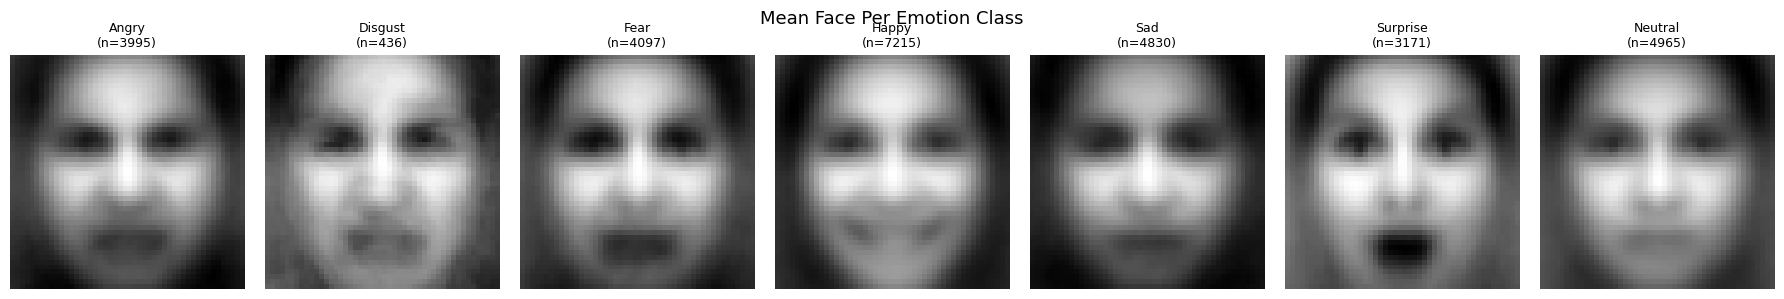

In [19]:
emotion_labels = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

fig, axes = plt.subplots(1, 7, figsize=(18, 3))
for cls in range(7):
    mask = train_df['emotion'].values == cls
    mean_face = train_images[mask].mean(axis=0)
    axes[cls].imshow(mean_face, cmap='gray')
    axes[cls].set_title(f"{emotion_labels[cls]}\n(n={mask.sum()})", fontsize=9)
    axes[cls].axis('off')

plt.suptitle("Mean Face Per Emotion Class", fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
print(f"{'Class':<5} {'Label':<12} {'Mean Variance'}")
print("-" * 34)
for cls in range(7):
    mask = train_df['emotion'].values == cls
    class_var = train_images[mask].reshape(mask.sum(), -1).var(axis=1).mean()
    print(f"{cls:<5} {emotion_labels[cls]:<12} {class_var:.2f}")

Class Label        Mean Variance
----------------------------------
0     Angry        3147.35
1     Disgust      2922.63
2     Fear         3172.00
3     Happy        2987.00
4     Sad          3085.23
5     Surprise     3209.35
6     Neutral      3159.98


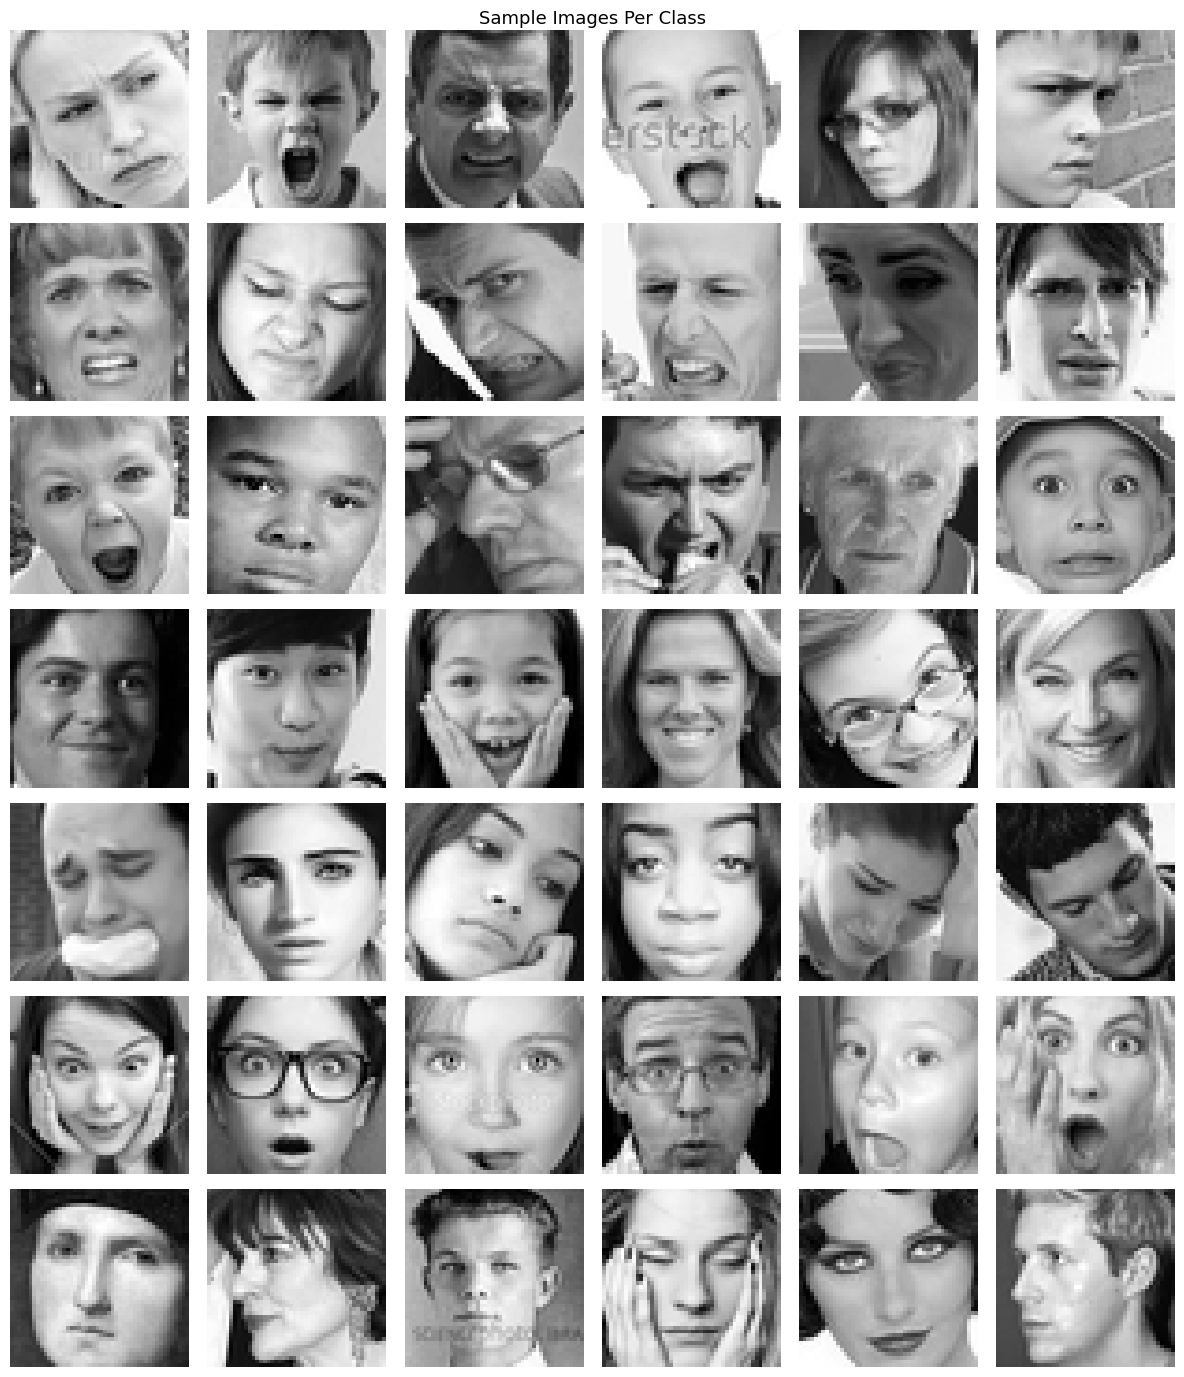

In [21]:
fig, axes = plt.subplots(7, 6, figsize=(12, 14))
for cls in range(7):
    mask = np.where(train_df['emotion'].values == cls)[0]
    samples = np.random.choice(mask, 6, replace=False)
    for j, idx in enumerate(samples):
        axes[cls][j].imshow(train_images[idx], cmap='gray')
        axes[cls][j].axis('off')
        if j == 0:
            axes[cls][j].set_ylabel(emotion_labels[cls], fontsize=9, rotation=90, labelpad=40)

plt.suptitle("Sample Images Per Class", fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
duplicate_mask = train_df.duplicated(subset='pixels', keep=False)
dup_df = train_df[duplicate_mask].copy()

print(f"Total rows involved in pixel-level duplicates: {len(dup_df)}")
print(f"Unique duplicate pixel strings: {dup_df['pixels'].nunique()}")

# Check if any duplicates have conflicting labels
conflict = (
    dup_df.groupby('pixels')['emotion']
    .nunique()
    .gt(1)
    .sum()
)
print(f"Duplicate pixel strings with conflicting labels: {conflict}")

Total rows involved in pixel-level duplicates: 2271
Unique duplicate pixel strings: 1035
Duplicate pixel strings with conflicting labels: 39


In [23]:
train_pixel_set = set(train_df['pixels'].values)
test_pixel_set  = set(test_df['pixels'].values)

leaked = train_pixel_set & test_pixel_set
print(f"Test images that appear verbatim in training set: {len(leaked)}")
print(f"That is {len(leaked)/len(test_pixel_set)*100:.2f}% of the test set")

Test images that appear verbatim in training set: 531
That is 7.49% of the test set


In [24]:
train_means = train_images.reshape(len(train_images), -1).mean(axis=1)
test_means  = test_images.reshape(len(test_images),  -1).mean(axis=1)

train_stds = train_images.reshape(len(train_images), -1).std(axis=1)
test_stds  = test_images.reshape(len(test_images),  -1).std(axis=1)

print("Per-image mean — Train: {:.2f} ± {:.2f}  |  Test: {:.2f} ± {:.2f}".format(
    train_means.mean(), train_means.std(),
    test_means.mean(),  test_means.std()))

print("Per-image std  — Train: {:.2f} ± {:.2f}  |  Test: {:.2f} ± {:.2f}".format(
    train_stds.mean(), train_stds.std(),
    test_stds.mean(),  test_stds.std()))

Per-image mean — Train: 129.47 ± 33.51  |  Test: 129.03 ± 33.57
Per-image std  — Train: 54.03 ± 13.67  |  Test: 54.18 ± 13.65


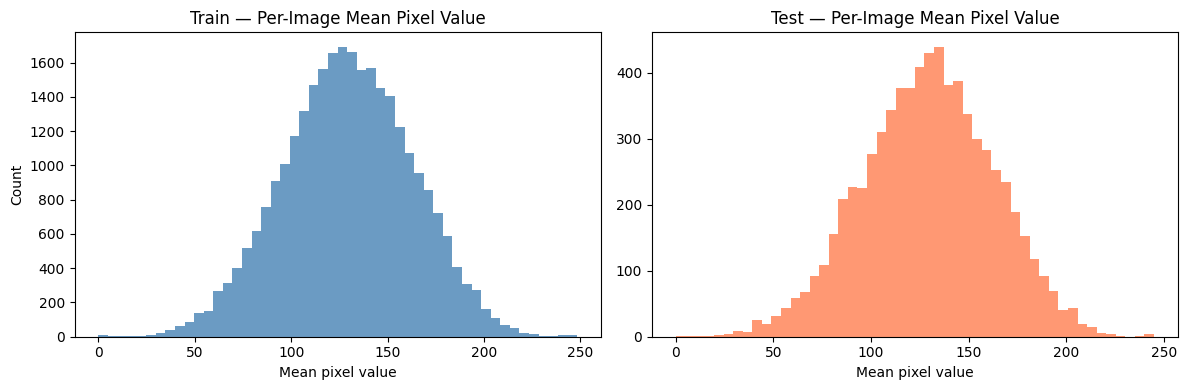

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_means, bins=50, color='steelblue', alpha=0.8)
axes[0].set_title("Train — Per-Image Mean Pixel Value")
axes[0].set_xlabel("Mean pixel value")
axes[0].set_ylabel("Count")

axes[1].hist(test_means, bins=50, color='coral', alpha=0.8)
axes[1].set_title("Test — Per-Image Mean Pixel Value")
axes[1].set_xlabel("Mean pixel value")

plt.tight_layout()
plt.show()

In [26]:
summary = {
    "Horizontal flip":     "SAFE   — faces are symmetric; does not change emotion label",
    "Vertical flip":       "UNSAFE — inverted faces are not natural expressions",
    "Rotation (±15°)":     "SAFE   — small rotations reflect natural head tilt",
    "Zoom / crop":         "SAFE   — faces are already centered; mild zoom preserves features",
    "Brightness jitter":   "SAFE   — helps generalize across lighting conditions",
    "Gaussian noise":      "SAFE   — adds robustness to image quality variation",
    "Cutout / erasing":    "SAFE   — occlusion robustness; keep patches small",
    "Color jitter (hue)":  "N/A    — grayscale dataset",
    "Disgust oversampling":"RECOMMENDED — 16.55x imbalance ratio warrants targeted augmentation",
}

print(f"{'Augmentation':<28} {'Verdict'}")
print("-" * 75)
for aug, verdict in summary.items():
    print(f"{aug:<28} {verdict}")

Augmentation                 Verdict
---------------------------------------------------------------------------
Horizontal flip              SAFE   — faces are symmetric; does not change emotion label
Vertical flip                UNSAFE — inverted faces are not natural expressions
Rotation (±15°)              SAFE   — small rotations reflect natural head tilt
Zoom / crop                  SAFE   — faces are already centered; mild zoom preserves features
Brightness jitter            SAFE   — helps generalize across lighting conditions
Gaussian noise               SAFE   — adds robustness to image quality variation
Cutout / erasing             SAFE   — occlusion robustness; keep patches small
Color jitter (hue)           N/A    — grayscale dataset
Disgust oversampling         RECOMMENDED — 16.55x imbalance ratio warrants targeted augmentation
